In [2]:
import kagglehub

# Download latest version
eye_datasheet = kagglehub.dataset_download("prasadvpatil/mrl-dataset")

yawn_datasheet = kagglehub.dataset_download("davidvazquezcic/yawn-dataset")

print("Path to dataset files:", eye_datasheet)
print("Path to dataset files:", yawn_datasheet)

100%|██████████| 22.6M/22.6M [00:02<00:00, 9.59MB/s]

Extracting files...


100%|██████████| 16.9M/16.9M [00:02<00:00, 7.95MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/prasadvpatil/mrl-dataset/versions/4
Path to dataset files: /root/.cache/kagglehub/datasets/davidvazquezcic/yawn-dataset/versions/1


In [3]:
import os

print("Eye dataset:")
print(os.listdir(eye_datasheet))

print("\nYawn dataset:")
print(os.listdir(yawn_datasheet))

Eye dataset:
['train']

Yawn dataset:
['yawn', 'no yawn']


In [4]:
train_path = eye_datasheet + "/train"

print(os.listdir(train_path))

['Closed_Eyes', 'Open_Eyes']


In [5]:
closed_path = train_path + "/Closed_Eyes"
open_path = train_path + "/Open_Eyes"

print("Closed:", len(os.listdir(closed_path)))
print("Open:", len(os.listdir(open_path)))

Closed: 2000
Open: 2000


In [6]:
import shutil
import random

base_dir = "/content/eye_data"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")

os.makedirs(train_dir + "/open", exist_ok=True)
os.makedirs(train_dir + "/closed", exist_ok=True)
os.makedirs(val_dir + "/open", exist_ok=True)
os.makedirs(val_dir + "/closed", exist_ok=True)

closed_images = os.listdir(closed_path)
open_images = os.listdir(open_path)

random.shuffle(closed_images)
random.shuffle(open_images)

split_closed = int(0.8 * len(closed_images))
split_open = int(0.8 * len(open_images))

for img in closed_images[:split_closed]:
    shutil.copy(os.path.join(closed_path, img), train_dir + "/closed")

for img in closed_images[split_closed:]:
    shutil.copy(os.path.join(closed_path, img), val_dir + "/closed")

for img in open_images[:split_open]:
    shutil.copy(os.path.join(open_path, img), train_dir + "/open")

for img in open_images[split_open:]:
    shutil.copy(os.path.join(open_path, img), val_dir + "/open")

In [7]:
print("Train closed:", len(os.listdir(train_dir + "/closed")))
print("Train open:", len(os.listdir(train_dir + "/open")))
print("Val closed:", len(os.listdir(val_dir + "/closed")))
print("Val open:", len(os.listdir(val_dir + "/open")))

Train closed: 1600
Train open: 1600
Val closed: 400
Val open: 400


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (64, 64)
batch_size = 32

train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    "/content/eye_data/train",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary"
)

val_data = val_gen.flow_from_directory(
    "/content/eye_data/val",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary"
)

Found 3200 images belonging to 2 classes.
Found 800 images belonging to 2 classes.


In [9]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=8
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 286ms/step - accuracy: 0.7978 - loss: 0.4068 - val_accuracy: 0.9800 - val_loss: 0.0642
Epoch 2/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 28s 282ms/step - accuracy: 0.9651 - loss: 0.0987 - val_accuracy: 0.9962 - val_loss: 0.0184
Epoch 3/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 265ms/step - accuracy: 0.9814 - loss: 0.0587 - val_accuracy: 0.9925 - val_loss: 0.0217
Epoch 4/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 271ms/step - accuracy: 0.9952 - loss: 0.0157 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoch 5/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 28s 279ms/step - accuracy: 0.9983 - loss: 0.0055 - val_accuracy: 0.9975 - val_loss: 0.0245
Epoch 6/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 28s 280ms/step - accuracy: 0.9941 - loss: 0.0207 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 7/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 38s 255ms/step - accuracy: 0.9969 - loss: 0.0098 - val_accuracy: 0.9975 - val_loss: 0.0063
Epoch 8/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 28s 280ms/step - accuracy: 0.9975 - loss: 0.0063 - 

In [12]:
model.save("/content/eye_state_model.h5")

In [13]:
yawn_path = yawn_datasheet + "/yawn"
no_yawn_path = yawn_datasheet + "/no yawn"

yawn_base = "/content/yawn_data"

yawn_train = os.path.join(yawn_base, "train")
yawn_val = os.path.join(yawn_base, "val")

os.makedirs(yawn_train + "/yawn", exist_ok=True)
os.makedirs(yawn_train + "/no_yawn", exist_ok=True)
os.makedirs(yawn_val + "/yawn", exist_ok=True)
os.makedirs(yawn_val + "/no_yawn", exist_ok=True)

yawn_images = os.listdir(yawn_path)
no_yawn_images = os.listdir(no_yawn_path)

random.shuffle(yawn_images)
random.shuffle(no_yawn_images)

split_yawn = int(0.8 * len(yawn_images))
split_no_yawn = int(0.8 * len(no_yawn_images))

for img in yawn_images[:split_yawn]:
    shutil.copy(os.path.join(yawn_path, img), yawn_train + "/yawn")

for img in yawn_images[split_yawn:]:
    shutil.copy(os.path.join(yawn_path, img), yawn_val + "/yawn")

for img in no_yawn_images[:split_no_yawn]:
    shutil.copy(os.path.join(no_yawn_path, img), yawn_train + "/no_yawn")

for img in no_yawn_images[split_no_yawn:]:
    shutil.copy(os.path.join(no_yawn_path, img), yawn_val + "/no_yawn")

In [14]:
train_data = train_gen.flow_from_directory(
    "/content/yawn_data/train",
    target_size=(64,64),
    batch_size=32,
    class_mode="binary"
)

val_data = val_gen.flow_from_directory(
    "/content/yawn_data/val",
    target_size=(64,64),
    batch_size=32,
    class_mode="binary"
)

Found 4094 images belonging to 2 classes.
Found 1025 images belonging to 2 classes.


In [15]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=8
)

Epoch 1/8
128/128 ━━━━━━━━━━━━━━━━━━━━ 33s 261ms/step - accuracy: 0.7398 - loss: 1.1526 - val_accuracy: 0.9190 - val_loss: 0.2140
Epoch 2/8
128/128 ━━━━━━━━━━━━━━━━━━━━ 34s 268ms/step - accuracy: 0.9329 - loss: 0.2092 - val_accuracy: 0.9473 - val_loss: 0.1494
Epoch 3/8
128/128 ━━━━━━━━━━━━━━━━━━━━ 36s 279ms/step - accuracy: 0.9556 - loss: 0.1468 - val_accuracy: 0.9561 - val_loss: 0.1282
Epoch 4/8
128/128 ━━━━━━━━━━━━━━━━━━━━ 34s 264ms/step - accuracy: 0.9617 - loss: 0.1137 - val_accuracy: 0.9649 - val_loss: 0.0972
Epoch 5/8
128/128 ━━━━━━━━━━━━━━━━━━━━ 34s 266ms/step - accuracy: 0.9663 - loss: 0.1031 - val_accuracy: 0.9639 - val_loss: 0.1018
Epoch 6/8
128/128 ━━━━━━━━━━━━━━━━━━━━ 42s 272ms/step - accuracy: 0.9718 - loss: 0.0941 - val_accuracy: 0.9610 - val_loss: 0.1048
Epoch 7/8
128/128 ━━━━━━━━━━━━━━━━━━━━ 35s 271ms/step - accuracy: 0.9726 - loss: 0.0827 - val_accuracy: 0.9698 - val_loss: 0.0829
Epoch 8/8
128/128 ━━━━━━━━━━━━━━━━━━━━ 35s 270ms/step - accuracy: 0.9785 - loss: 0.0633 - 

In [16]:
model.save("/content/yawn_model.h5")

In [17]:
from tensorflow.keras.models import load_model
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Load model
eye_model = load_model("/content/eye_state_model.h5")

# Eye validation generator
eye_val = val_gen.flow_from_directory(
    "/content/eye_data/val",
    target_size=(64,64),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

# Predictions
pred = eye_model.predict(eye_val)
pred_classes = (pred > 0.5).astype(int).reshape(-1)

true_classes = eye_val.classes

# Accuracy
acc = accuracy_score(true_classes, pred_classes)
print("Eye Model Accuracy:", acc)

# Confusion Matrix
cm = confusion_matrix(true_classes, pred_classes)
print("Eye Confusion Matrix:\n", cm)

# Precision Recall F1
print(classification_report(true_classes, pred_classes))

Found 800 images belonging to 2 classes.
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step
Eye Model Accuracy: 1.0
Eye Confusion Matrix:
 [[400   0]
 [  0 400]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       1.00      1.00      1.00       400

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



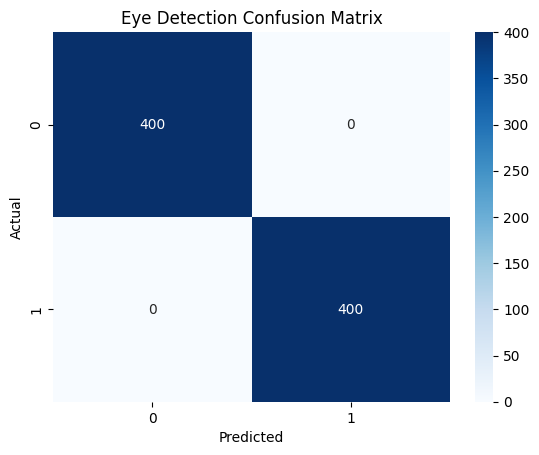

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Eye Detection Confusion Matrix")
plt.show()

In [19]:
# Load model
yawn_model = load_model("/content/yawn_model.h5")

# Yawn validation generator
yawn_val = val_gen.flow_from_directory(
    "/content/yawn_data/val",
    target_size=(64,64),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

pred = yawn_model.predict(yawn_val)
pred_classes = (pred > 0.5).astype(int).reshape(-1)

true_classes = yawn_val.classes

acc = accuracy_score(true_classes, pred_classes)
print("Yawn Model Accuracy:", acc)

cm = confusion_matrix(true_classes, pred_classes)
print("Yawn Confusion Matrix:\n", cm)

print(classification_report(true_classes, pred_classes))

Found 1025 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step
Yawn Model Accuracy: 0.975609756097561
Yawn Confusion Matrix:
 [[505  14]
 [ 11 495]]
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       519
           1       0.97      0.98      0.98       506

    accuracy                           0.98      1025
   macro avg       0.98      0.98      0.98      1025
weighted avg       0.98      0.98      0.98      1025



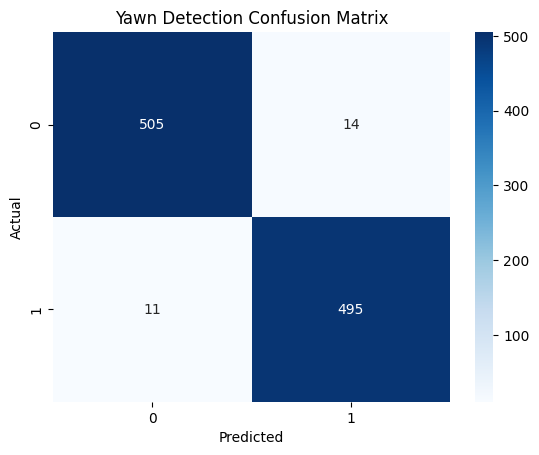

In [20]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Yawn Detection Confusion Matrix")
plt.show()